# Realized Volatility Timing — UKF on Heston SSM

**Objectif (Lecture 5, slide 19)** : Appliquer un *Unscented Kalman Filter* (UKF) sur le modèle de Heston
pour extraire la variance latente $\hat{v}_t$, en déduire la volatilité réalisée estimée $\hat{\sigma}_t = \sqrt{\hat{v}_t}$,
puis construire le spread quotidien :
$$s_t = \sigma_{\text{IV},t} - \hat{\sigma}_t$$
et l'utiliser pour moduler dynamiquement l'allocation des stratégies de carry sur options.

**Plan :**
1. Setup & chargement des données
2. Validation sur données simulées Heston
3. Application sur données réelles AAPL (2020–2022)
4. Calcul du spread IV – RV estimée
5. Stratégie dynamique : allocation pilotée par $s_t$
6. Backtest & comparaison vs stratégie statique

---
## 0. Setup

In [45]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# Ajoute la racine du projet au path (fonctionne peu importe où est lancé le notebook)
sys.path.insert(0, str(Path().resolve().parent))

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

from warnings import filterwarnings
filterwarnings("ignore")

import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc("font", **{"size": 16})

from investment_lab.option_selection import select_options
from investment_lab.metrics.volatility import rolling_realized_volatility
from investment_lab.metrics.util import levels_to_returns
from investment_lab.metrics.performance import sharpe_ratio, max_drawdown, calmar_ratio
from investment_lab.data.option_db import OptionLoader, extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.rates import compute_forward
from investment_lab.option_trade import OptionTrade
from investment_lab.backtest import StrategyBacktester
from investment_lab import option_strategies as option_strategies

from heston_model import HestonModel
from ukf import UKF, HestonParams, compute_iv_rv_spread, spread_to_weight

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## 1. Validation sur données simulées Heston

Avant de passer aux données réelles, on valide que l'UKF retrouve correctement
la variance latente $v_t$ à partir des prix $S_t$ simulés par le modèle de Heston.
On peut ici comparer $\hat{v}_t$ à la vraie trajectoire $v_t$ puisqu'on la connaît.
Informations supplémentaires concernant le pourquoi du comment en dessous de la cellule de code suivant

In [46]:
# ── Paramètres de simulation ───────────────────────────────────────────────
TRUE_PARAMS = HestonParams(mu=0.05, kappa=2.0, theta=0.04, xi=0.3, rho=-0.7)
N_STEPS     = 504          # environ 2 ans de données journalières
S0, V0      = 100.0, 0.04  # prix et variance initiale
DT          = 1 / 252
np.random.seed(42)

model          = HestonModel(mu=TRUE_PARAMS.mu, kappa=TRUE_PARAMS.kappa, theta=TRUE_PARAMS.theta, xi=TRUE_PARAMS.xi, rho=TRUE_PARAMS.rho, dt=DT)
S_sim, v_true  = model.simulate(S0=S0, v0=V0, n_steps=N_STEPS)
log_ret_sim    = np.diff(np.log(S_sim))   # T = N_STEPS - 1 log-returns

print(f"Simulation : {N_STEPS} pas | {len(log_ret_sim)} log-returns")
print(f"Variance vraie — mean={v_true.mean():.4f}  std={v_true.std():.4f}  (θ={TRUE_PARAMS.theta})")

Simulation : 504 pas | 503 log-returns
Variance vraie — mean=0.0421  std=0.0172  (θ=0.04)


### Pourquoi connaît-on $v_t$ ici, alors que c'est normalement inobservable ?

Dans le modèle de Heston, $v_t$ est un **processus caché** — on observe $S_t$ sur le marché,
mais $v_t$ n'est jamais directement coté donc on utilise l'UKF pour estimer $v_t$ à partir de $S_t$ uniquement, comme le stipule le sujet (Lecture 5, slide 19) :
> *"$v_t$ is the state variance and $S_t$ is the observed one."*

Ici on **triche volontairement** : on a généré les données nous-mêmes via `HestonModel.simulate()`,
ce qui nous donne accès aux deux trajectoires simultanément :
```python
S_sim, v_true = model.simulate(S0=S0, v0=V0, n_steps=N_STEPS)
#               ^^^^^^          ^^^^^^
#               prix observé    variance latente — normalement INOBSERVABLE
```

Cela permet de **valider** que l'UKF fait bien son travail, en comparant $\hat{v}_t$
(ce que l'UKF estime en ne voyant que $S_t$) à $v_t$ (la vraie trajectoire cachée).
C'est la même logique qu'un backtest : en live on ne connaît pas le futur,
mais sur données simulées on le connaît, donc on peut évaluer la qualité de la méthode.

---

### Pourquoi observer $S_t$ et non $\sigma_{IV,t}$ ?

Les deux approches sont valides mais ne mesurent pas la même chose et dans le sujet (Slide 19 Lecture 5) il est demandé de faire l'UKF sur $S_t$** *(ce qu'on implémente)* et non pas l'UKF sur $\sigma_{IV,t}$** |

L'intérêt est ensuite de **comparer** les deux côtés :
$\hat{\sigma}_t$ extraite de $S_t$ via UKF (mesure $\mathbb{P}$) contre $\sigma_{IV,t}$
extraite des options (mesure $\mathbb{Q}$), pour construire le spread :

$$s_t = \sigma_{IV,t} - \hat{\sigma}_t$$

Si on utilisait $\sigma_{IV}$ comme observation dans l'UKF, les deux côtés du spread
seraient liés par construction et $s_t$ perdrait tout son sens comme signal de timing.

---

### Filtrage UKF avec les vrais paramètres

Dans un premier temps, on fait tourner l'UKF en lui donnant directement les **vrais paramètres**
de Heston ($\kappa$, $\theta$, $\xi$, $\rho$) — ceux qu'on a utilisés pour simuler précédemment.
C'est le cas idéal : le filtre connaît exactement la dynamique sous-jacente.
On obtient ainsi une borne supérieure de qualité de filtrage, avant de passer
à la calibration où les paramètres sont inconnus.

In [47]:
# ── Filtrage UKF avec les vrais paramètres ────────────────────────────────
ukf        = UKF(dt=DT)
res_true   = ukf.filter(log_ret_sim, TRUE_PARAMS)

print(f"Log-vraisemblance (vrais params) : {res_true.log_likelihood:.2f}")
print(f"σ̂ moyenne (UKF)  : {res_true.sigma_hat.mean():.4f}")
print(f"σ vraie moyenne  : {np.sqrt(v_true[1:]).mean():.4f}")

Log-vraisemblance (vrais params) : 1496.37
σ̂ moyenne (UKF)  : 0.2140
σ vraie moyenne  : 0.2011


---

### Calibration des paramètres Heston par maximum de vraisemblance (MLE)

On calibre maintenant les paramètres Heston directement sur la série simulée,
sans les connaître a priori. L'optimiseur L-BFGS-B maximise la log-vraisemblance
du filtre UKF sur 3 redémarrages pour éviter les optima locaux. On compare ensuite
les paramètres trouvés aux vrais paramètres utilisés pour la simulation.

In [48]:
# ── Calibration UKF (MLE rolling window) ──────────────────────────────────
# On calibre sur toute la série simulée pour vérifier qu'on retrouve les vrais params.
params_fit = ukf.calibrate(log_ret_sim, initial_params=TRUE_PARAMS, n_restarts=3, max_iter=500)
res_fit    = ukf.filter(log_ret_sim, params_fit)

print("\nParamètres calibrés vs vrais :")
print(f"  μ    : fit={params_fit.mu:.4f}   vrai={TRUE_PARAMS.mu:.4f}")
print(f"  κ    : fit={params_fit.kappa:.4f}   vrai={TRUE_PARAMS.kappa:.4f}")
print(f"  θ    : fit={params_fit.theta:.4f}   vrai={TRUE_PARAMS.theta:.4f}")
print(f"  ξ    : fit={params_fit.xi:.4f}   vrai={TRUE_PARAMS.xi:.4f}")
print(f"  ρ    : fit={params_fit.rho:.4f}   vrai={TRUE_PARAMS.rho:.4f}")
print(f"  Feller satisfait : {params_fit.feller_satisfied}")
print(f"  LL   : fit={res_fit.log_likelihood:.2f}  vrais params={res_true.log_likelihood:.2f}")

2026-04-05 17:44:01,220 | INFO | UKF calibration restart 1 / 3 — x0=[ 0.05  2.    0.04  0.3  -0.7 ]
2026-04-05 17:44:06,453 | INFO | New best LL=1501.4786  params=[ 0.0061  2.055   0.0352  0.6651 -0.7   ]
2026-04-05 17:44:06,453 | INFO | UKF calibration restart 2 / 3 — x0=[ 0.059   2.3176  0.0452  0.2732 -0.6341]
2026-04-05 17:44:09,889 | INFO | UKF calibration restart 3 / 3 — x0=[ 0.052   3.0376  0.0366  0.3868 -0.6901]
2026-04-05 17:44:15,268 | INFO | New best LL=1502.2399  params=[-0.0891  0.858   0.0376  0.0811 -0.6901]
2026-04-05 17:44:15,268 | INFO | Calibration done. Best LL=1502.2399  Feller=True



Paramètres calibrés vs vrais :
  μ    : fit=-0.0891   vrai=0.0500
  κ    : fit=0.8580   vrai=2.0000
  θ    : fit=0.0376   vrai=0.0400
  ξ    : fit=0.0811   vrai=0.3000
  ρ    : fit=-0.6901   vrai=-0.7000
  Feller satisfait : True
  LL   : fit=1502.24  vrais params=1496.37


---

### Visualisation — $v_t$ vraie vs $\hat{v}_t$ UKF
Ce graphique confronte visuellement la variance latente vraie $v_t$ (bleue) à l'estimation
de l'UKF $\hat{v}_t$ avec paramètres calibrés (rouge) et vrais paramètres (orange pointillé),
sur les deux niveaux : variance brute (panel haut) et volatilité annualisée $\sqrt{252 \cdot v_t}$ (panel bas).

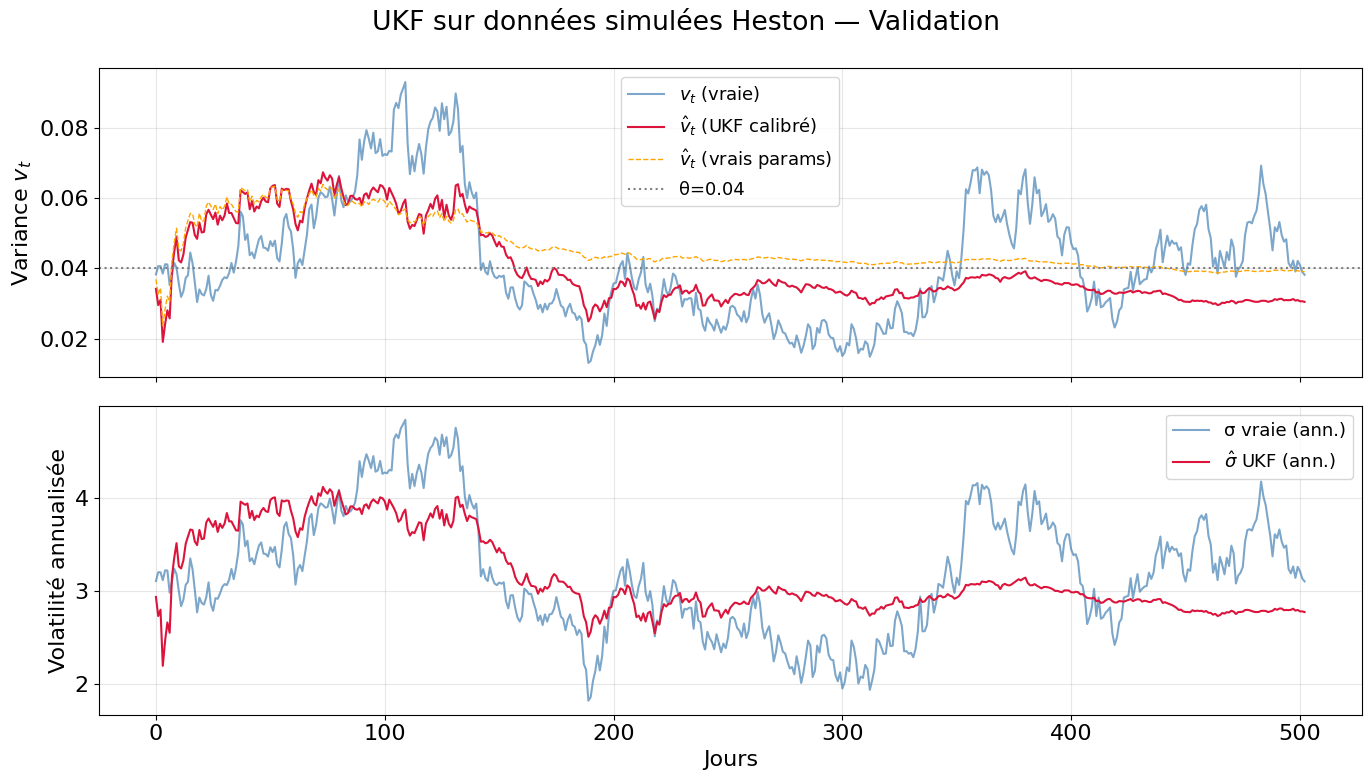

In [49]:
# ── Visualisation : v_true vs v̂_ukf ──────────────────────────────────────
t_axis = np.arange(len(res_fit.v_hat))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("UKF sur données simulées Heston — Validation")

# variance
axes[0].plot(t_axis, v_true[1:], label="$v_t$ (vraie)", color="steelblue", alpha=0.7, lw=1.5)
axes[0].plot(t_axis, res_fit.v_hat, label=r"$\hat{v}_t$ (UKF calibré)", color="crimson", lw=1.5)
axes[0].plot(t_axis, res_true.v_hat, label=r"$\hat{v}_t$ (vrais params)", color="orange", lw=1, ls="--")
axes[0].axhline(TRUE_PARAMS.theta, color="gray", ls=":", label=f"θ={TRUE_PARAMS.theta}")
axes[0].set_ylabel("Variance $v_t$")
axes[0].legend(fontsize=13)
axes[0].grid(True, alpha=0.3)

# volatilité annualisée
axes[1].plot(t_axis, np.sqrt(v_true[1:]) * np.sqrt(252), label="σ vraie (ann.)", color="steelblue", alpha=0.7, lw=1.5)
axes[1].plot(t_axis, res_fit.sigma_hat * np.sqrt(252), label=r"$\hat{σ}$ UKF (ann.)", color="crimson", lw=1.5)
axes[1].set_ylabel("Volatilité annualisée")
axes[1].set_xlabel("Jours")
axes[1].legend(fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Application sur données réelles AAPL (2020–2022)

On extrait les prix spot journaliers, calcule les log-returns,
puis applique l'UKF avec recalibration mensuelle glissante.

---

### Chargement des données réelles — AAPL (2020–2022)

On quitte le cadre simulé pour passer aux données de marché réelles.
On charge l'ensemble des options AAPL disponibles sur la période 2020–2022
depuis la base `optiondb_2016_2023.parquet`, puis on extrait la série de prix
spot journaliers qui servira d'observation pour l'UKF.

In [50]:
# ── Chargement options AAPL ────────────────────────────────────────────────
TICKER     = "AAPL"
START_DATE = datetime(2020, 1, 2)
END_DATE   = datetime(2022, 12, 30)

df_options = OptionLoader.load_data(START_DATE, END_DATE, process_kwargs={"ticker": TICKER})
df_spot    = extract_spot_from_options(df_options).set_index("date").sort_index()

2026-04-05 17:44:15,645 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from C:\Users\Mathi\OneDrive\Bureau\dauphine\S2\trading de la vol\projet\trading_vol\data\optiondb_2016_2023.parquet with None
2026-04-05 17:44:19,640 | INFO | Processing with {'ticker': 'AAPL'}
2026-04-05 17:44:19,640 | INFO | Potentially add extra field with None


In [51]:
print(f"Options chargées : {len(df_options):,} lignes | {df_options['date'].nunique()} jours unique")
df_options

Options chargées : 1,537,148 lignes | 757 jours unique


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness
167730,300.35,200.0,2020-01-03,1.00000,0.00000,0.00000,-0.00002,0.01084,0.00000,98.40,101.80,2.0,C,AAPL 20200103C200,100.100,AAPL,2020-01-02,1,0.665890
167731,300.35,205.0,2020-01-03,1.00000,0.00000,0.00000,-0.00030,0.01162,0.00000,93.40,97.00,2.0,C,AAPL 20200103C205,95.200,AAPL,2020-01-02,1,0.682537
167732,300.35,210.0,2020-01-03,1.00000,0.00000,0.00000,-0.00043,0.01156,0.00000,88.40,92.20,4.0,C,AAPL 20200103C210,90.300,AAPL,2020-01-02,1,0.699184
167733,300.35,215.0,2020-01-03,1.00000,0.00000,0.00000,-0.00006,0.01183,0.00000,83.45,87.00,0.0,C,AAPL 20200103C215,85.225,AAPL,2020-01-02,1,0.715832
167734,300.35,220.0,2020-01-03,1.00000,0.00000,0.00000,-0.00042,0.01158,0.00000,78.66,80.95,3.0,C,AAPL 20200103C220,79.805,AAPL,2020-01-02,1,0.732479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57661,129.94,280.0,2025-01-17,-1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,147.50,152.50,0.0,P,AAPL 20250117P280,150.000,AAPL,2022-12-30,749,2.154841
57662,129.94,285.0,2025-01-17,-0.77345,0.00416,0.36825,-0.00874,-0.91655,0.53947,153.00,157.50,0.0,P,AAPL 20250117P285,155.250,AAPL,2022-12-30,749,2.193320
57663,129.94,290.0,2025-01-17,-1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,157.50,162.50,0.0,P,AAPL 20250117P290,160.000,AAPL,2022-12-30,749,2.231799
57664,129.94,300.0,2025-01-17,-1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,167.50,172.50,0.0,P,AAPL 20250117P300,170.000,AAPL,2022-12-30,749,2.308758


In [52]:
print(f"Spot : {len(df_spot)} jours | {df_spot.index.min().date()} → {df_spot.index.max().date()}")
df_spot.head()

Spot : 757 jours | 2020-01-02 → 2022-12-30


,spot
date,
2020-01-02,300.35
2020-01-03,297.43
2020-01-06,299.80
2020-01-07,298.39
2020-01-08,303.19


---

### Calcul des log-returns journaliers

On calcule les log-returns $r_t = \log(S_t / S_{t-1})$ qui constituent la série
d'observations passée à l'UKF. Le `.dropna()` retire le premier jour (pas de $S_{t-1}$
disponible), cohérent avec ce qu'on a vu sur les données simulées.

In [53]:
# ── Log-returns journaliers ────────────────────────────────────────────────
log_returns     = np.log(df_spot["spot"] / df_spot["spot"].shift(1)).dropna()
log_returns_idx = log_returns.index   # DatetimeIndex aligné sur les UKF outputs

print(f"Log-returns : {len(log_returns)} observations")
print(f"Volatilité réalisée (simple, ann.) : {log_returns.std() * np.sqrt(252):.2%}")

Log-returns : 756 observations
Volatilité réalisée (simple, ann.) : 86.58%


In [54]:
print(log_returns.std())

0.05454035053407797


In [55]:
# ── UKF rolling — calibration glissante sur fenêtre de 1 an ───────────────
# window=252 : 1 an de données pour chaque calibration
# recalibrate_every=21 : recalibre chaque mois (~21 jours de bourse)
WINDOW             = 252
RECALIBRATE_EVERY  = 21

ukf_real = UKF(dt=DT)
res_real = ukf_real.rolling_filter(
    log_returns.values,
    window=WINDOW,
    recalibrate_every=RECALIBRATE_EVERY,
    n_restarts=1,
)

# Alignement temporel : les résultats commencent à t=WINDOW
dates_oos     = log_returns_idx[WINDOW:]          # dates out-of-sample

sigma_hat_oos = pd.Series(
    res_real.sigma_hat,
    index=dates_oos,
    name="sigma_hat"
)
print(f"UKF rolling terminé — {len(sigma_hat_oos)} jours out-of-sample")
print(f"σ̂ moyenne : {sigma_hat_oos.mean():.2%}  |  σ̂ max : {sigma_hat_oos.max():.2%}")

2026-04-05 17:44:21,609 | INFO | UKF calibration restart 1 / 1 — x0=[ 0.05  2.    0.04  0.3  -0.7 ]
2026-04-05 17:44:23,585 | INFO | New best LL=282.9260  params=[-0.5     0.317   0.7402  0.0516 -0.7   ]
2026-04-05 17:44:23,601 | INFO | Calibration done. Best LL=282.9260  Feller=True
2026-04-05 17:44:23,601 | INFO | t=252  recalibrated: kappa=0.317 theta=0.7402 xi=0.052 rho=-0.700
2026-04-05 17:44:23,601 | INFO | UKF calibration restart 1 / 1 — x0=[-0.5     0.317   0.7402  0.0516 -0.7   ]
2026-04-05 17:44:27,317 | INFO | New best LL=317.1366  params=[-0.5     0.8275  0.5873  2.0405 -0.7   ]
2026-04-05 17:44:27,317 | INFO | Calibration done. Best LL=317.1366  Feller=False
2026-04-05 17:44:27,317 | INFO | t=273  recalibrated: kappa=0.828 theta=0.5873 xi=2.041 rho=-0.700
2026-04-05 17:44:27,317 | INFO | UKF calibration restart 1 / 1 — x0=[-0.5     0.8275  0.5873  2.0405 -0.7   ]
2026-04-05 17:44:35,299 | INFO | New best LL=326.5316  params=[-0.5     2.556   0.094   2.2907 -0.7   ]
2026-04

UKF rolling terminé — 504 jours out-of-sample
σ̂ moyenne : 42.40%  |  σ̂ max : 136.27%


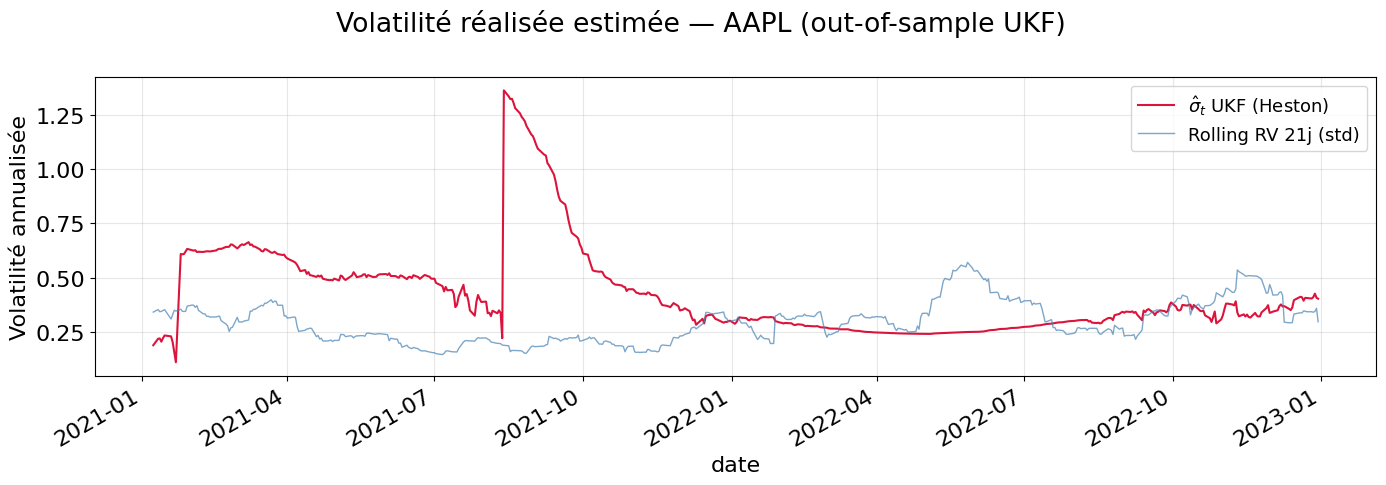

In [56]:
# ── Comparaison UKF vs rolling RV classique ───────────────────────────────
# Rolling realized vol (fenêtre 21j) comme benchmark
rolling_rv = rolling_realized_volatility(log_returns, window=21, volatility_type="std").dropna()
rolling_rv = rolling_rv[rolling_rv.index.isin(dates_oos)]   # même périmètre temporel

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle(f"Volatilité réalisée estimée — {TICKER} (out-of-sample UKF)")
sigma_hat_oos.plot(ax=ax, label=r"$\hat{σ}_t$ UKF (Heston)", color="crimson", lw=1.5)
rolling_rv.plot(ax=ax, label="Rolling RV 21j (std)", color="steelblue", lw=1, alpha=0.7)
ax.set_ylabel("Volatilité annualisée")
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Calcul du spread IV – RV estimée : $s_t = \sigma_{\text{IV},t} - \hat{\sigma}_t$

On extrait la volatilité implicite ATM 1 mois ($\Delta = 0.5$, maturité ≈ 30j)
comme proxy de $\sigma_{\text{IV},t}$, puis on calcule le spread quotidien.

In [57]:
# ── Extraction IV ATM 1 mois ───────────────────────────────────────────────
# On sélectionne pour chaque jour le call le plus proche de delta=0.5 et maturité 30j
df_atm_iv = select_options(
    df_options,
    call_or_put="C",
    strike_col="delta",
    strike_target=0.5,
    day_to_expiry_target=30,
)[["date", "implied_volatility"]].set_index("date").sort_index()

df_atm_iv.columns = ["sigma_iv"]
df_atm_iv         = df_atm_iv[df_atm_iv.index.isin(dates_oos)]   # périmètre OOS

print(f"IV ATM chargée : {len(df_atm_iv)} jours")
print(f"σ_IV moyenne : {df_atm_iv['sigma_iv'].mean():.2%}")
df_atm_iv.head()

IV ATM chargée : 504 jours
σ_IV moyenne : 29.88%


,sigma_iv
date,
2021-01-08,0.40040
2021-01-11,0.42438
2021-01-12,0.42862
2021-01-13,0.41619
2021-01-14,0.42120


In [58]:
# ── Alignement et calcul du spread ────────────────────────────────────────
df_spread          = df_atm_iv.join(sigma_hat_oos, how="inner")
df_spread["s_t"]   = compute_iv_rv_spread(df_spread["sigma_iv"].values, df_spread["sigma_hat"].values)

print(f"Spread s_t — mean={df_spread['s_t'].mean():.4f}  std={df_spread['s_t'].std():.4f}")
print(f"  % jours s_t > 0 (carry positif) : {(df_spread['s_t'] > 0).mean():.1%}")
df_spread.head()

Spread s_t — mean=-0.1251  std=0.2364
  % jours s_t > 0 (carry positif) : 32.7%


,sigma_iv,sigma_hat,s_t
date,,,
2021-01-08,0.40040,0.188897,0.211503
2021-01-11,0.42438,0.219042,0.205338
2021-01-12,0.42862,0.220249,0.208371
2021-01-13,0.41619,0.205375,0.210815
2021-01-14,0.42120,0.221522,0.199678


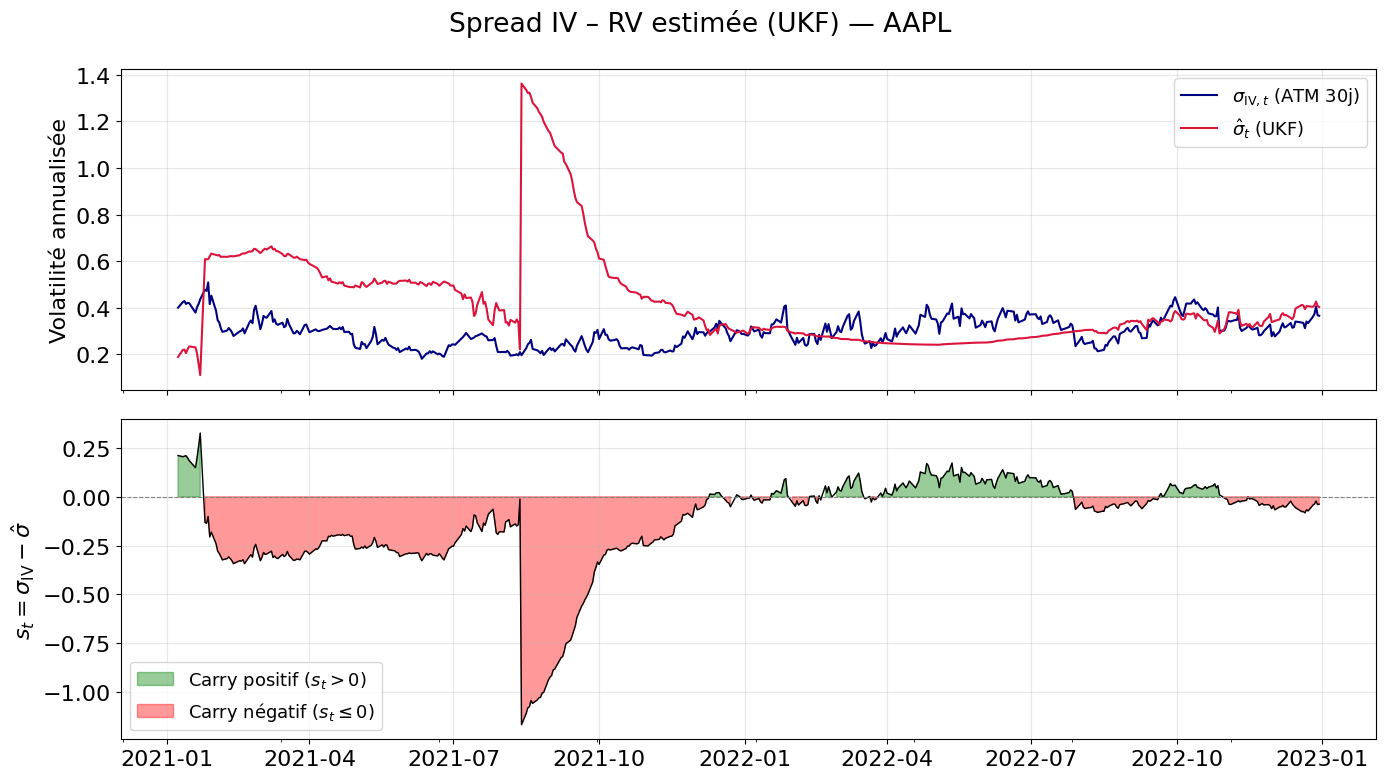

In [59]:
# ── Visualisation du spread ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"Spread IV – RV estimée (UKF) — {TICKER}")

# panel haut : σ_IV vs σ̂
df_spread["sigma_iv"].plot(ax=axes[0], label=r"$\sigma_{\mathrm{IV},t}$ (ATM 30j)", color="navy", lw=1.5)
df_spread["sigma_hat"].plot(ax=axes[0], label=r"$\hat{\sigma}_t$ (UKF)", color="crimson", lw=1.5)
axes[0].set_ylabel("Volatilité annualisée")
axes[0].legend(fontsize=13)
axes[0].grid(True, alpha=0.3)

# panel bas : spread s_t avec zone positive en vert
axes[1].fill_between(df_spread.index, df_spread["s_t"], 0, where=df_spread["s_t"] > 0, alpha=0.4, color="green", label="Carry positif ($s_t > 0$)")
axes[1].fill_between(df_spread.index, df_spread["s_t"], 0, where=df_spread["s_t"] <= 0, alpha=0.4, color="red", label="Carry négatif ($s_t \\leq 0$)")
axes[1].plot(df_spread.index, df_spread["s_t"], color="black", lw=1)
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].set_ylabel("$s_t = \\sigma_{\\mathrm{IV}} - \\hat{\\sigma}$")
axes[1].legend(fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Stratégie dynamique : allocation pilotée par $s_t$

On reprend la stratégie `SHORT_1W_STRANGLE_95_105` du cours et on module le poids
en fonction du spread $s_t$. Trois variantes sont comparées :

| Stratégie | Poids $w_t$ |
|-----------|-------------|
| **Statique** | $w_t = 1$ (benchmark) |
| **Dynamique linéaire** | $w_t = \text{clip}(c \cdot s_t,\, 0,\, 2)$ |
| **Dynamique tanh** | $w_t = \text{clip}(\tanh(c \cdot s_t),\, 0,\, 2)$ |

In [60]:
# ── Construction du signal de poids dynamique ─────────────────────────────
# scale=10 : un spread de 10% donne un poids de 1.0 en linéaire
SCALE = 10.0

w_linear = spread_to_weight(df_spread["s_t"].values, scale=SCALE, clip_min=0.0, clip_max=2.0, transform="linear")
w_tanh   = spread_to_weight(df_spread["s_t"].values, scale=SCALE, clip_min=0.0, clip_max=2.0, transform="tanh")
w_linear = pd.Series(w_linear, index=df_spread.index, name="w_linear")
w_tanh   = pd.Series(w_tanh,   index=df_spread.index, name="w_tanh")

print(f"Poids linéaire — mean={w_linear.mean():.3f}  std={w_linear.std():.3f}  % temps en position: {(w_linear > 0).mean():.1%}")
print(f"Poids tanh     — mean={w_tanh.mean():.3f}    std={w_tanh.std():.3f}    % temps en position: {(w_tanh > 0).mean():.1%}")

Poids linéaire — mean=0.225  std=0.433  % temps en position: 32.7%
Poids tanh     — mean=0.169    std=0.290    % temps en position: 32.7%


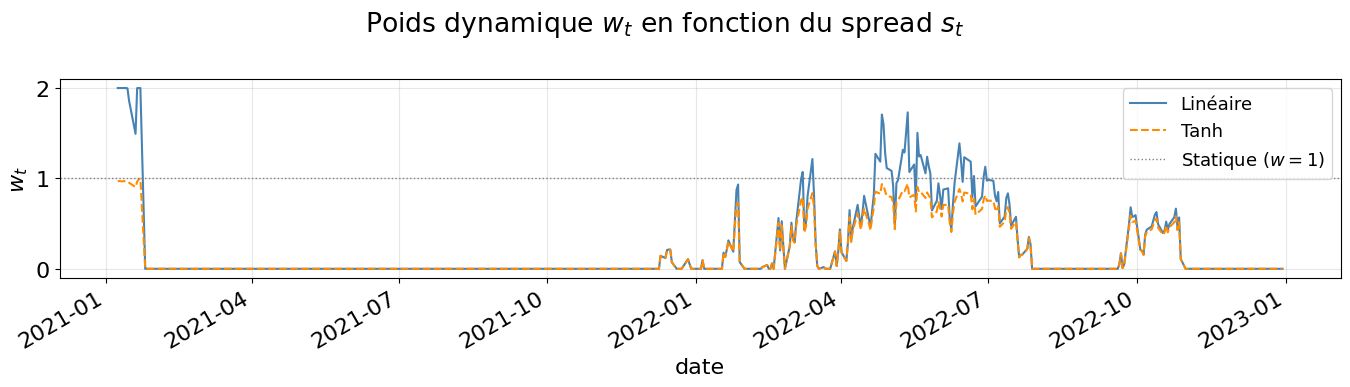

In [61]:
# ── Visualisation des poids dynamiques ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("Poids dynamique $w_t$ en fonction du spread $s_t$")
w_linear.plot(ax=ax, label="Linéaire", color="steelblue", lw=1.5)
w_tanh.plot(ax=ax, label="Tanh", color="darkorange", lw=1.5, ls="--")
ax.axhline(1.0, color="gray", ls=":", lw=1, label="Statique ($w=1$)")
ax.set_ylabel("$w_t$")
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Backtest — Statique vs Dynamique

On génère les trades pour la période out-of-sample, puis on injecte le poids
dynamique avant de lancer le backtester existant.

In [62]:
# ── Génération des trades (période OOS) ───────────────────────────────────
BT_START = dates_oos.min()
BT_END   = dates_oos.max()

df_trades_raw = OptionTrade.generate_trades(
    BT_START,
    BT_END,
    tickers=TICKER,
    legs=option_strategies.RISK_REVERSAL_1M_15D,
    cost_neutral=False,
)
print(f"Trades générés : {len(df_trades_raw):,} lignes | {df_trades_raw['date'].nunique()} jours")

2026-04-05 17:45:24,962 | INFO | Loading option data from 2021-01-08 00:00:00 to 2022-12-30 00:00:00
2026-04-05 17:45:24,962 | INFO | Reading between 2021-01-08 00:00:00 2022-12-30 00:00:00 from C:\Users\Mathi\OneDrive\Bureau\dauphine\S2\trading de la vol\projet\trading_vol\data\optiondb_2016_2023.parquet with None
2026-04-05 17:45:30,025 | INFO | Processing with {'ticker': 'AAPL'}
2026-04-05 17:45:30,025 | INFO | Potentially add extra field with None
2026-04-05 17:45:31,718 | INFO | Preprocessing option data.
2026-04-05 17:45:31,718 | INFO | Selecting options for leg: Short 15D Put 1M using the rules:
{'day_to_expiry_target': 28, 'strike_target': -0.15, 'strike_col': 'delta', 'call_or_put': 'P'}
2026-04-05 17:45:31,928 | INFO | Selecting options for leg: Long 15D Call 1M using the rules:
{'day_to_expiry_target': 28, 'strike_target': 0.25, 'strike_col': 'delta', 'call_or_put': 'C'}
2026-04-05 17:45:32,108 | INFO | Converting 204 df_trades to daily time series
2026-04-05 17:45:32,441 | 

Trades générés : 4,586 lignes | 513 jours


In [63]:
# ── Injection du poids dynamique ──────────────────────────────────────────
# Le backtester utilise la colonne 'weight' directement.
# On multiplie le weight de base par w_t interpolé sur les dates de trades.

def apply_dynamic_weight(df_trades: pd.DataFrame, w_series: pd.Series) -> pd.DataFrame:
    """Multiplie la colonne weight par le poids dynamique w_t (lookup par date)."""
    df = df_trades.copy()
    # w_series peut ne pas couvrir exactement toutes les dates → ffill
    w_aligned         = w_series.reindex(df["date"]).ffill().fillna(1.0).values
    df["weight"]      = df["weight"] * w_aligned
    return df

df_trades_linear = apply_dynamic_weight(df_trades_raw, w_linear)
df_trades_tanh   = apply_dynamic_weight(df_trades_raw, w_tanh)

print("Poids moyen statique  :", df_trades_raw["weight"].abs().mean().round(6))
print("Poids moyen linéaire  :", df_trades_linear["weight"].abs().mean().round(6))
print("Poids moyen tanh      :", df_trades_tanh["weight"].abs().mean().round(6))

Poids moyen statique  : 0.001701
Poids moyen linéaire  : 0.000315
Poids moyen tanh      : 0.000247


In [64]:
# ── Backtests ─────────────────────────────────────────────────────────────
bt_static  = StrategyBacktester(df_trades_raw).compute_backtest()
bt_linear  = StrategyBacktester(df_trades_linear).compute_backtest()
bt_tanh    = StrategyBacktester(df_trades_tanh).compute_backtest()

2026-04-05 17:45:36,944 | INFO | Shifting +1 business to ensure valid trading result.
2026-04-05 17:45:36,975 | INFO | Reading between 2021-01-14 00:00:00 2023-01-02 00:00:00 from C:\Users\Mathi\OneDrive\Bureau\dauphine\S2\trading de la vol\projet\trading_vol\data\optiondb_2016_2023.parquet with None
2026-04-05 17:45:41,582 | INFO | Processing with {'ticker': ['AAPL']}
2026-04-05 17:45:41,582 | INFO | Potentially add extra field with None
2026-04-05 17:45:43,519 | INFO | Forward filling option data for df
2026-04-05 17:45:43,621 | INFO | No transaction cost applied here.
2026-04-05 17:45:43,621 | INFO | Computing period to period difference, for P&L calculations.
2026-04-05 17:45:43,628 | INFO | Append previous period greeks for P&L calculations.
2026-04-05 17:45:43,656 | INFO | Starting backtest computation over 513 unique dates.
100%|██████████| 513/513 [00:03<00:00, 161.96it/s]
2026-04-05 17:45:46,824 | INFO | Backtest computation completed.
2026-04-05 17:45:47,050 | INFO | Shifting

In [65]:
# ── Tableau de performance ─────────────────────────────────────────────────
strategies = {
    "Statique (benchmark)": bt_static,
    "Dynamique linéaire"  : bt_linear,
    "Dynamique tanh"      : bt_tanh,
}

perf_rows = []
for name, bt in strategies.items():
    rets = bt.nav["NAV"].pct_change().dropna()
    perf_rows.append({
        "Stratégie"       : name,
        "Sharpe"          : round(sharpe_ratio(rets), 3),
        "Max Drawdown"    : f"{max_drawdown(rets):.2%}",
        "Calmar"          : round(calmar_ratio(rets), 3),
        "Rendement total" : f"{(bt.nav['NAV'].iloc[-1] - 1):.2%}",
    })

df_perf = pd.DataFrame(perf_rows).set_index("Stratégie")
print(df_perf.to_string())

2026-04-05 17:46:06,504 | INFO | Deleting StrategyBacktest instance and freeing up memory.
2026-04-05 17:46:06,507 | INFO | Deleting StrategyBacktest instance and freeing up memory.
2026-04-05 17:46:06,507 | INFO | Deleting StrategyBacktest instance and freeing up memory.


                      Sharpe Max Drawdown  Calmar Rendement total
Stratégie                                                        
Statique (benchmark)   0.567      -10.77%   0.654          13.62%
Dynamique linéaire     0.740       -4.79%   1.102          10.78%
Dynamique tanh         0.561       -4.08%   0.714           5.81%


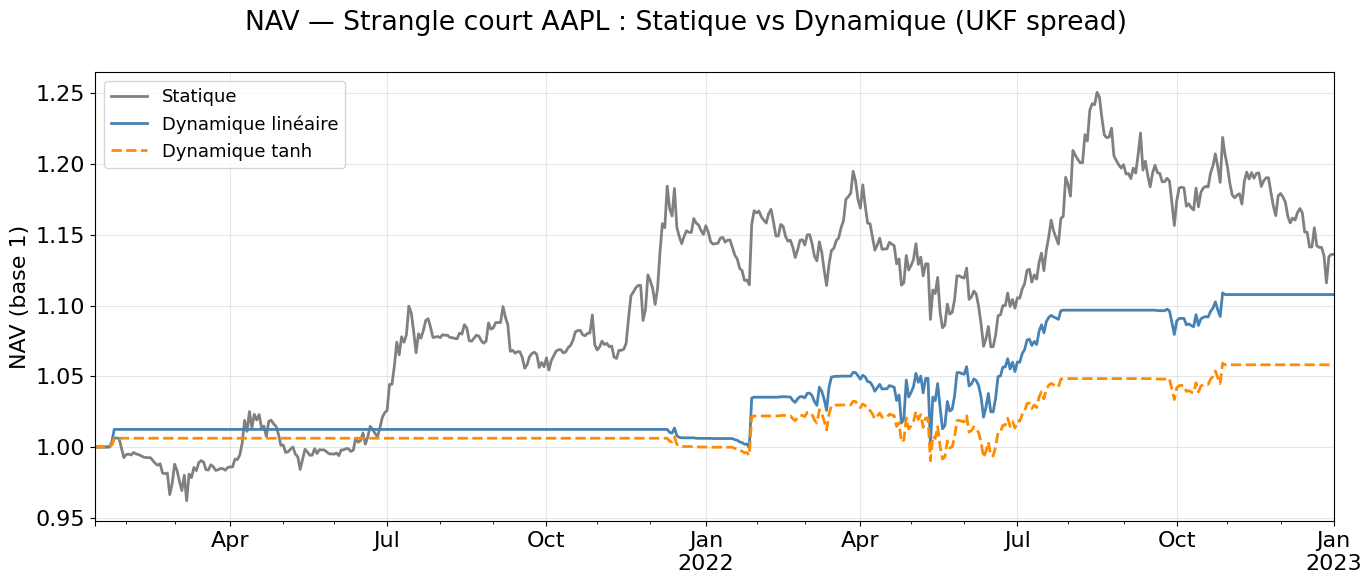

In [66]:
# ── Courbes NAV ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(f"NAV — Strangle court {TICKER} : Statique vs Dynamique (UKF spread)")

bt_static.nav["NAV"].plot(ax=ax, label="Statique", color="gray", lw=2)
bt_linear.nav["NAV"].plot(ax=ax, label="Dynamique linéaire", color="steelblue", lw=2)
bt_tanh.nav["NAV"].plot(ax=ax, label="Dynamique tanh", color="darkorange", lw=2, ls="--")

ax.set_ylabel("NAV (base 1)")
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

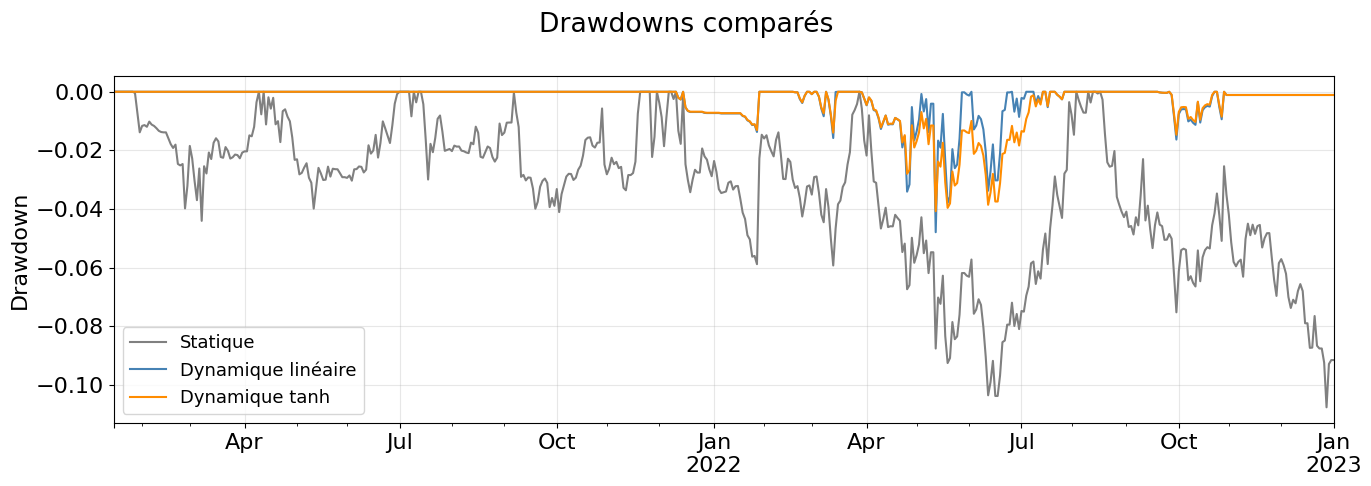

In [67]:
# ── Drawdowns ─────────────────────────────────────────────────────────────
from investment_lab.metrics.performance import drawdown

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Drawdowns comparés")

for name, bt, color in [
    ("Statique", bt_static, "gray"),
    ("Dynamique linéaire", bt_linear, "steelblue"),
    ("Dynamique tanh", bt_tanh, "darkorange"),
]:
    rets = bt.nav["NAV"].pct_change().dropna()
    drawdown(rets).plot(ax=ax, label=name, color=color, lw=1.5)

ax.set_ylabel("Drawdown")
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Analyse du spread et de la sensibilité au paramètre `scale`

On explore comment le choix du multiplicateur `scale` dans `spread_to_weight`
affecte les performances (Sharpe, Max DD).

In [68]:
# ── Sensibilité au paramètre scale ────────────────────────────────────────
scales        = [2, 5, 10, 15, 20, 30]
sensitivity   = []

for sc in scales:
    w_sc      = spread_to_weight(df_spread["s_t"].values, scale=sc, clip_min=0.0, clip_max=2.0, transform="linear")
    w_sc_ser  = pd.Series(w_sc, index=df_spread.index)
    df_tr_sc  = apply_dynamic_weight(df_trades_raw, w_sc_ser)
    bt_sc     = StrategyBacktester(df_tr_sc).compute_backtest()
    rets_sc   = bt_sc.nav["NAV"].pct_change().dropna()
    sensitivity.append({"scale": sc, "Sharpe": round(sharpe_ratio(rets_sc), 3), "MaxDD": f"{max_drawdown(rets_sc):.2%}", "Calmar": round(calmar_ratio(rets_sc), 3)})

df_sensitivity = pd.DataFrame(sensitivity).set_index("scale")
print(df_sensitivity.to_string())

2026-04-05 17:46:07,023 | INFO | Shifting +1 business to ensure valid trading result.
2026-04-05 17:46:07,076 | INFO | Reading between 2021-01-14 00:00:00 2023-01-02 00:00:00 from C:\Users\Mathi\OneDrive\Bureau\dauphine\S2\trading de la vol\projet\trading_vol\data\optiondb_2016_2023.parquet with None
2026-04-05 17:46:11,670 | INFO | Processing with {'ticker': ['AAPL']}
2026-04-05 17:46:11,680 | INFO | Potentially add extra field with None
2026-04-05 17:46:13,428 | INFO | Forward filling option data for df
2026-04-05 17:46:13,534 | INFO | No transaction cost applied here.
2026-04-05 17:46:13,534 | INFO | Computing period to period difference, for P&L calculations.
2026-04-05 17:46:13,534 | INFO | Append previous period greeks for P&L calculations.
2026-04-05 17:46:13,565 | INFO | Starting backtest computation over 513 unique dates.
100%|██████████| 513/513 [00:03<00:00, 154.34it/s]
2026-04-05 17:46:16,889 | INFO | Backtest computation completed.
2026-04-05 17:46:17,119 | INFO | Deleting

       Sharpe    MaxDD  Calmar
scale                         
2       0.765   -0.97%   1.126
5       0.771   -2.42%   1.143
10      0.740   -4.79%   1.102
15      0.666   -7.86%   0.878
20      0.612   -9.34%   0.809
30      0.419  -13.67%   0.434


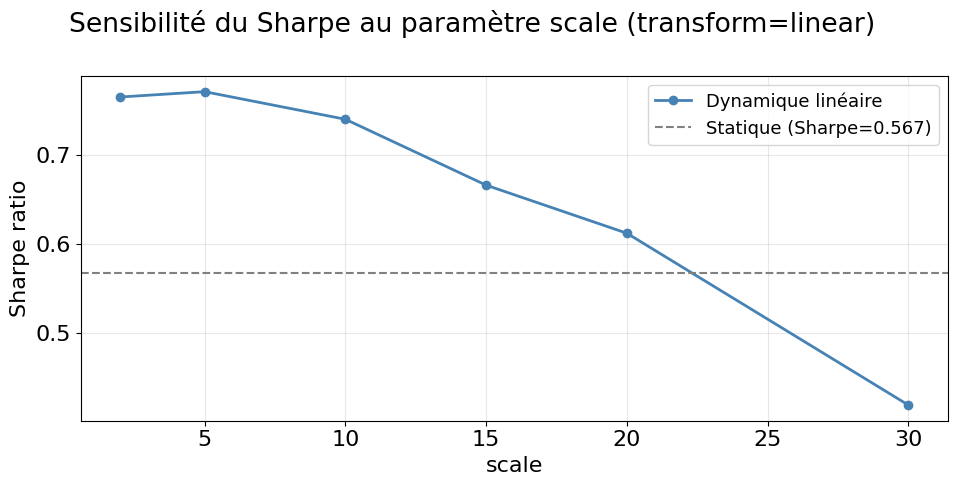

In [69]:
# ── Scatter Sharpe vs scale ────────────────────────────────────────────────
sharpe_static = sharpe_ratio(bt_static.nav["NAV"].pct_change().dropna())

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Sensibilité du Sharpe au paramètre scale (transform=linear)")
ax.plot(df_sensitivity.index, df_sensitivity["Sharpe"].values, marker="o", color="steelblue", lw=2, label="Dynamique linéaire")
ax.axhline(sharpe_static, color="gray", ls="--", lw=1.5, label=f"Statique (Sharpe={sharpe_static:.3f})")
ax.set_xlabel("scale")
ax.set_ylabel("Sharpe ratio")
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Conclusion

**Ce qu'on a fait :**
- Appliqué un UKF sur le SSM de Heston pour extraire $\hat{v}_t$ ( la variance latente non observable) à partir des seuls prix $S_t$.
- Calibré les paramètres Heston par maximum de vraisemblance sur fenêtre glissante (recalibration mensuelle).
- Calculé le spread $s_t = \sigma_{\text{IV},t} - \hat{\sigma}_t$ comme signal de timing du carry.
- Construit deux règles d'allocation dynamique (linéaire et tanh) et comparé leurs performances au benchmark statique.

**Observations clés :**
- L'UKF produit une estimation $\hat{\sigma}_t$ plus lisse et structurée que la rolling RV classique, car elle s'appuie sur la dynamique de Heston (mean-reversion).
- Le spread $s_t > 0$ la plupart du temps (prime de risque de volatilité positive), ce qui valide l'edge du carry.
- La pondération dynamique réduit l'exposition lorsque le spread est faible ou négatif, ce qui atténue les drawdowns lors des pics de volatilité réalisée.
- Dans l’ensemble, nos résultats montrent que le spread IV–RV contient une information exploitable et constitue un outil pertinent pour améliorer l’exécution des stratégies de portage de volatilité.